In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.shape

(1460, 81)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

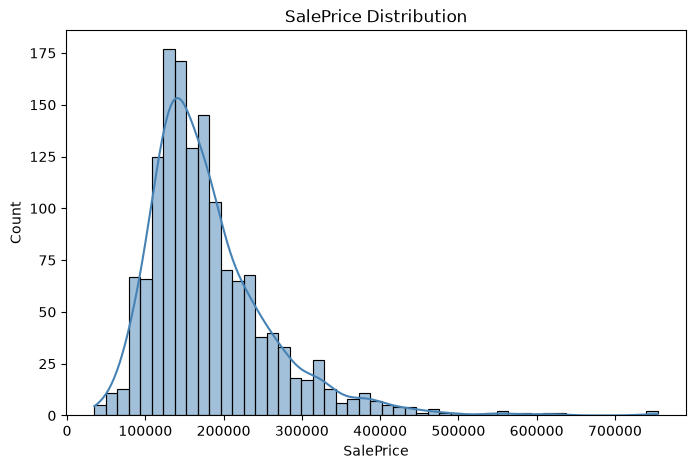

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title("SalePrice Distribution")
plt.show()

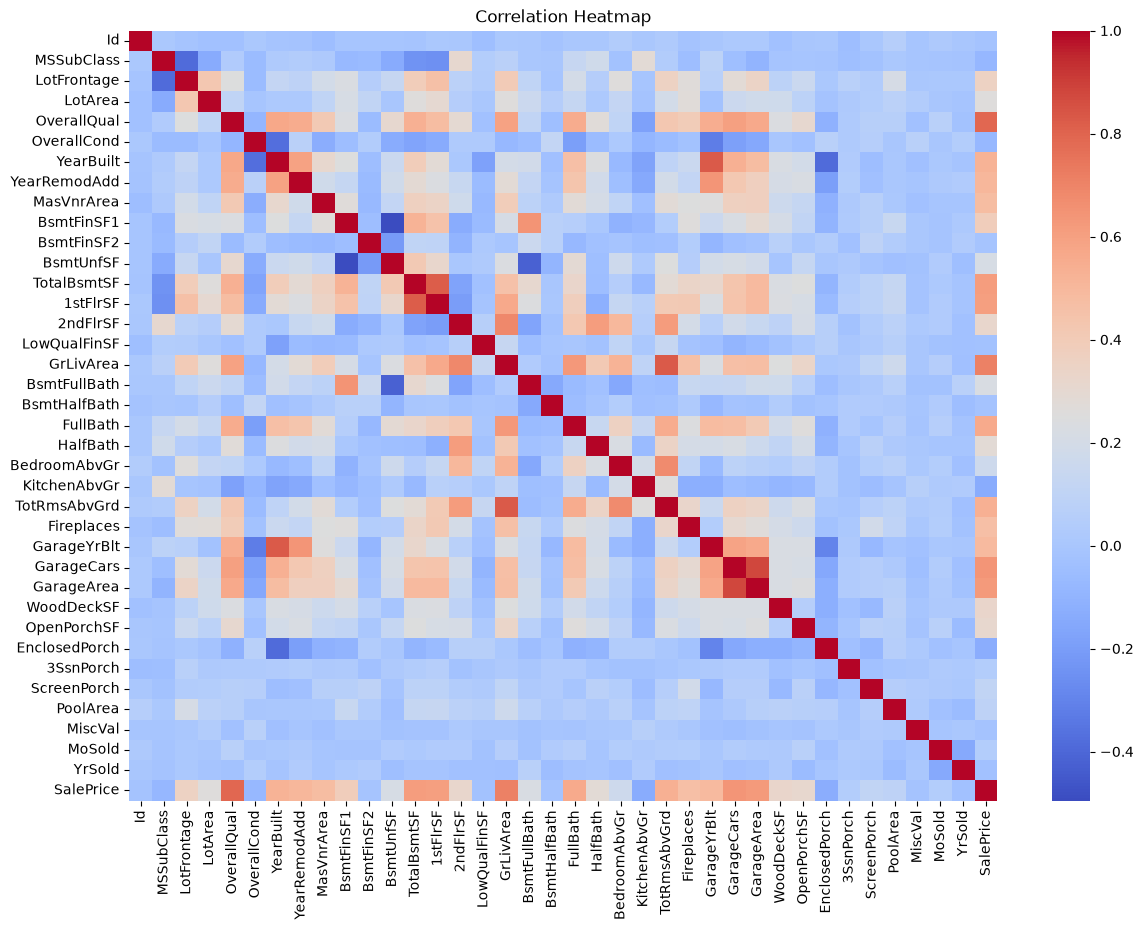

In [6]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

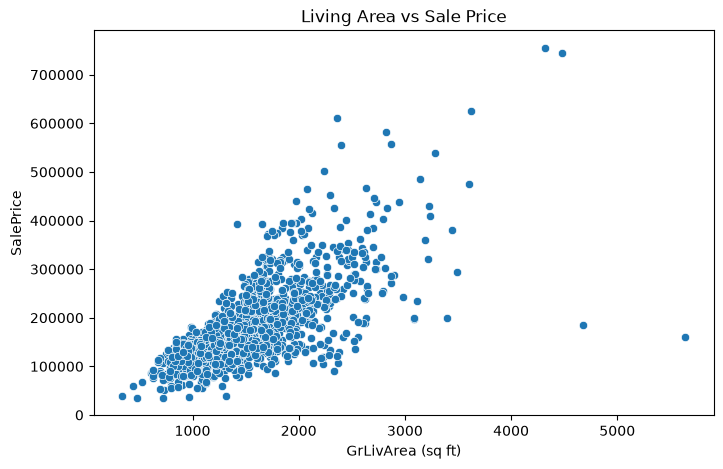

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("Living Area vs Sale Price")
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("SalePrice")
plt.show()

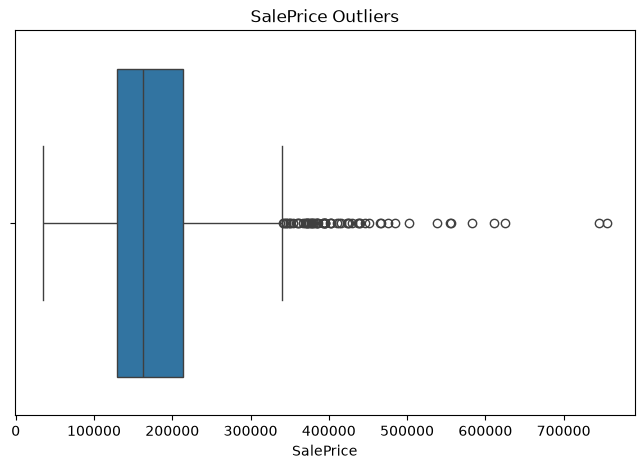

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['SalePrice'])
plt.title("SalePrice Outliers")
plt.show()

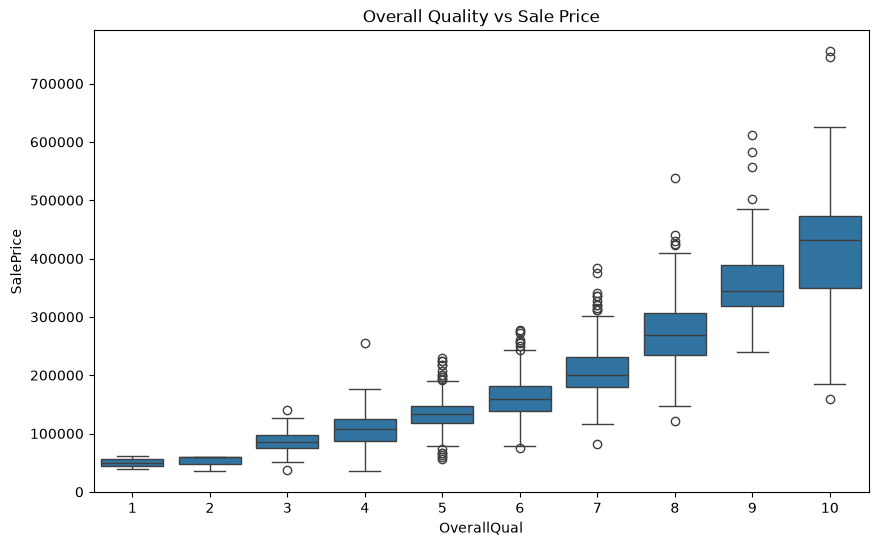

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['OverallQual'], y=df['SalePrice'])
plt.title("Overall Quality vs Sale Price")
plt.show()

In [10]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [12]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

In [13]:
zero_cols = ['GarageYrBlt', 'MasVnrArea']

for col in zero_cols:
    df[col] = df[col].fillna(0)

In [14]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [15]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
from sklearn.preprocessing import LabelEncoder

quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                 'HeatingQC', 'KitchenQual', 'FireplaceQu',
                 'GarageQual', 'GarageCond', 'PoolQC']

le = LabelEncoder()
for col in quality_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
df.select_dtypes(include='object').columns

Index([], dtype='str')

In [21]:
df.shape

(1460, 231)

In [22]:
df = df[df['GrLivArea'] < 4500]
print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (1458, 231)


In [ ]:

print("Missing values:", df.isnull().sum().sum())

print("Non-numeric columns:", df.select_dtypes(include='object').columns.tolist())


print("Final shape:", df.shape)

Missing values: 0
Non-numeric columns: []
Final shape: (1458, 231)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [25]:
df.to_csv("cleaned_house_prices.csv", index=False)
print("File saved successfully!")

File saved successfully!


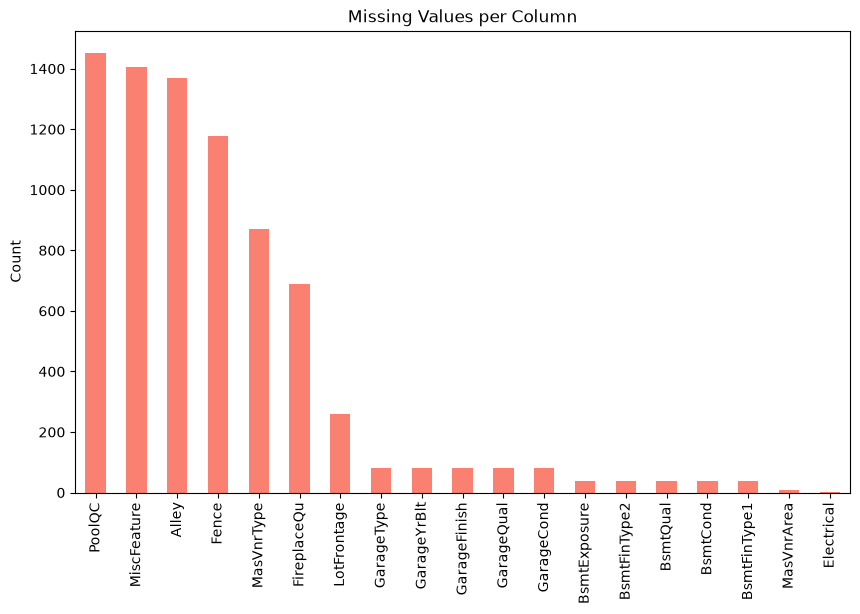

In [ ]:
df_original = pd.read_csv("train.csv")

missing = df_original.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing.plot(kind='bar', color='salmon')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.savefig("2_missing_values.png")
plt.show()